In [106]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv("HVAC Energy Data.csv")

# Have an idea of it
df.head()

,Local Time (Timezone : GMT+8h),Chilled Water Rate (L/sec),Cooling Water Temperature (C),Building Load (RT),Chiller Energy Consumption (kWh),Outside Temperature (F),Dew Point (F),Humidity (%),Wind Speed (mph),Pressure (in)
0,8/18/2019 0:00,85.6,31.4,479.6,116.2,82,75,79,13,29.83
1,8/18/2019 0:30,84.3,31.1,460.3,114.5,82,75,79,12,29.83
2,8/18/2019 1:00,84.6,31.3,462.4,116.8,82,75,79,12,29.83
3,8/18/2019 1:30,84.8,31.4,458.5,117.0,82,75,79,12,29.83
4,8/18/2019 2:00,84.7,31.4,455.4,117.0,82,75,79,12,29.83


## Data Pre-Processing

### Explanation of variables
• **Local Time**: when the measurement was recorded <br>
• **Chilled Water Rate (L/sec)**: flow rate of chilled water il Liters (L) per second (sec) <br>
• **Cooling Water Temperature (°C)**: the so called Tchws <br>
• **Building Load (RT)**: represents the cooling demand of the building in refrigeration tons (RT) <br>
• **Chiller Energy Consumption (kWh)**: the chiller's energy consumption in kilowatt-hours -> it's our target variable <br>
• **Outside Temperature (F)**: outside air temperature in Fahrenheit degrees <br>
• **Dew Point (F)**: outside dew point temperature in Fahreneit degrees <br>
• **Humidity (%)**: outside humidity in percentage <br>
• **Wind Speed (mph)**: wind speed in miles per hour <br>
• **Pressure (in)**: atmospheric pressure in inches of mercury <br>

In [107]:
# Check for datatypes and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13615 entries, 0 to 13614
Data columns (total 10 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Local Time (Timezone : GMT+8h)    13615 non-null  object 
 1   Chilled Water Rate (L/sec)        13615 non-null  float64
 2   Cooling Water Temperature (C)     13615 non-null  float64
 3   Building Load (RT)                13615 non-null  float64
 4   Chiller Energy Consumption (kWh)  13615 non-null  float64
 5   Outside Temperature (F)           13615 non-null  int64  
 6   Dew Point (F)                     13615 non-null  int64  
 7   Humidity (%)                      13615 non-null  int64  
 8   Wind Speed (mph)                  13615 non-null  int64  
 9   Pressure (in)                     13615 non-null  float64
dtypes: float64(5), int64(4), object(1)
memory usage: 1.0+ MB


In [108]:
# Rename columns for easier access
df.rename(columns={
    'Local Time (Timezone : GMT+8h)': 'Local Time',
    'Chilled Water Rate (L/sec)': 'Chilled Water Rate',
    'Cooling Water Temperature (°C)': 'Cooling Water Temperature',
    'Building Load (RT)': 'Building Load',
    'Chiller Energy Consumption (kWh)': 'Chiller Energy Consumption',
    'Outside Temperature (F)': 'Outside Temperature',
    'Dew Point (F)': 'Dew Point',
    'Humidity (%)': 'Humidity',
    'Wind Speed (mph)': 'Wind Speed',
    'Pressure (in)': 'Pressure'
}, inplace=True)

# Trasform Local Time to datetime
df['Local Time'] = pd.to_datetime(df['Local Time'])

# Trasform Outside Temperature and Dew Point from Fahrenheit to Celsius
df['Outside Temperature'] = (df['Outside Temperature'] - 32) * 5.0/9.0
df['Dew Point'] = (df['Dew Point'] - 32) * 5.0/9.0

# Now check for outliers
df.describe().round(2)

,Local Time,Chilled Water Rate,Cooling Water Temperature (C),Building Load,Chiller Energy Consumption,Outside Temperature,Dew Point,Humidity,Wind Speed,Pressure
count,13615,13615.00,13615.00,13615.00,13615.00,13615.00,13615.00,13615.00,13615.00,13615.00
mean,2020-01-09 14:44:46.448769792,96.74,31.62,520.94,126.81,28.39,23.88,77.85,6.31,29.81
min,2019-08-18 00:00:00,72.40,25.80,55.10,18.00,22.78,15.00,34.00,0.00,29.62
25%,2019-10-29 11:45:00,86.90,30.80,443.50,105.60,27.22,22.78,70.00,3.00,29.77
50%,2020-01-09 14:00:00,94.20,31.50,495.60,118.10,27.78,23.89,79.00,6.00,29.80
75%,2020-03-22 12:15:00,106.10,32.50,595.00,138.30,30.00,25.00,84.00,9.00,29.83
max,2020-06-01 13:00:00,141.50,36.20,1088.40,281.20,33.89,27.22,100.00,21.00,29.95
std,NaN,12.56,1.25,96.34,30.16,2.13,1.05,11.05,3.74,0.05


## LSTM Model

In [109]:
# Define feature variables and target variable
features = df.drop(columns=['Local Time', 'Chiller Energy Consumption'])
target = df['Chiller Energy Consumption']

# Standardize the feature variables
scaler_features = StandardScaler()
features_scaled = scaler_features.fit_transform(features)
scaler_target = StandardScaler()
target_scaled = scaler_target.fit_transform(target.values.reshape(-1, 1))

# Create 12h sequences for LSTM
def create_sequences(features, target, lookback):
    features_seq, target_seq = [], []
    for i in range(lookback, len(features)):
        features_seq.append(features[i-lookback:i])
        target_seq.append(target[i])
    return np.array(features_seq), np.array(target_seq)

lookback = 24  # 12h sequences (we have half-hour data)
features_seq, target_seq = create_sequences(features_scaled, target_scaled, lookback=lookback)

# Split into training and testing sets (80% - 20%) with no shuffle as it's time series data
split_index = int(0.8 * len(features_seq))
X_train, X_test = features_seq[:split_index], features_seq[split_index:]
y_train, y_test = target_seq[:split_index], target_seq[split_index:]

# Dimensions
n_timesteps = X_train.shape[1]   # Lookback
n_features = X_train.shape[2]

# Build the LSTM model
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model = Sequential([
    LSTM(64, input_shape=(n_timesteps, n_features), return_sequences=False),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1)  # Output layer
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), callbacks=[es], verbose=1)

# Check which epoch we take the best weights from
best_epoch = np.argmin(history.history['val_loss']) + 1  # indexes start at 0
best_val_loss = np.min(history.history['val_loss'])
print(f"\nRestored weights of epoch {best_epoch} with val_loss = {best_val_loss:.6f}")


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_13 (LSTM)                  │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,801 (81.25 KB)

 Trainable params: 20,801 (81.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.3850 - val_loss: 0.1818
Epoch 2/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2765 - val_loss: 0.1734
Epoch 3/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2331 - val_loss: 0.1706
Epoch 4/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2266 - val_loss: 0.1730
Epoch 5/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2083 - val_loss: 0.1718
Epoch 6/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2098 - val_loss: 0.1843
Epoch 7/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1984 - val_loss: 0.1735
Epoch 8/20
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1924 - val_loss: 0.1719

Restored weights of epoch 3 with val_loss = 0.170648


### Check for Overfitting

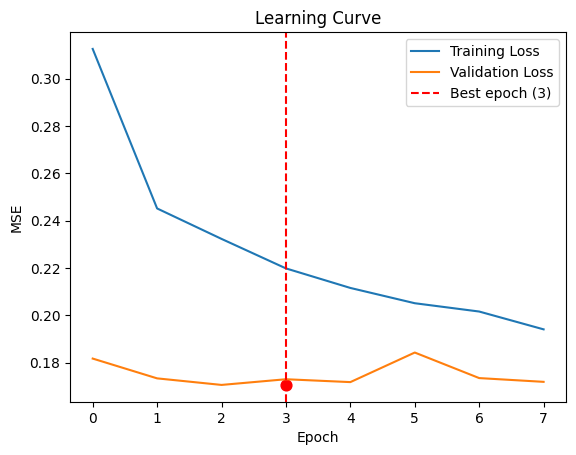

In [110]:
# Check for over/under fitting with learning curves
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best epoch ({best_epoch})') 
plt.scatter(best_epoch, best_val_loss, color='red', s=60)
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.title('Learning Curve')
plt.show()

### Evaluation of the Model & Results

MAE: 7.110 kWh
RMSE: 12.459 kWh
R²: 0.576


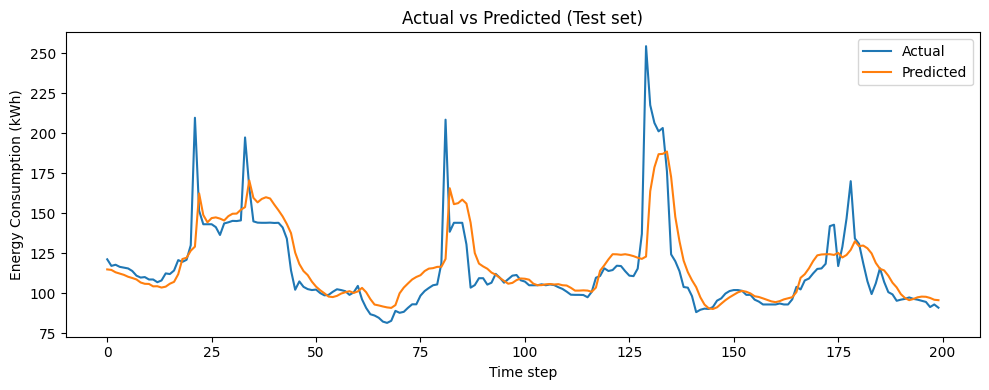

In [111]:
# Predict on test set
y_pred_scaled = model.predict(X_test, verbose=0)

# Remove the standardization (results in kWh)
y_true = scaler_target.inverse_transform(y_test)
y_pred = scaler_target.inverse_transform(y_pred_scaled)

# Compute evaluation metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE: {mae:.3f} kWh")
print(f"RMSE: {rmse:.3f} kWh")
print(f"R²: {r2:.3f}")

# See performance of the model for the first 200 time steps in the test set
plt.figure(figsize=(10,4))
plt.plot(y_true[:200], label='Actual', linewidth=1.5)
plt.plot(y_pred[:200], label='Predicted', linewidth=1.5)
plt.title('Actual vs Predicted (Test set)')
plt.xlabel('Time step')
plt.ylabel('Energy Consumption (kWh)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Return comparison between actual and predicted for the whole test set
y_true = np.squeeze(y_true)
y_pred = np.squeeze(y_pred)
error = y_true - y_pred

results = pd.DataFrame({
    'Actual (kWh)': y_true,
    'Predicted (kWh)': y_pred,
    'Error (kWh)': error
})

# Display first 20 rows of the results
results.head(20)  

,Actual (kWh),Predicted (kWh),Error (kWh)
0,121.2,114.896385,6.303615
1,117.1,114.565628,2.534372
2,117.8,113.098289,4.701711
3,116.5,112.259315,4.240685
4,116.0,111.487083,4.512917
5,115.5,110.306473,5.193527
6,113.9,109.526176,4.373824
7,111.0,108.624336,2.375664
8,109.8,106.731667,3.068333
9,110.1,105.908272,4.191728
